# Lifeboat: Titanic Survival Prediction

Complete notebook: EDA, model training, and inference for Titanic passenger survival prediction.

---

In [29]:
# Imports
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import accuracy_score, roc_auc_score, classification_report, confusion_matrix
import warnings
warnings.filterwarnings('ignore')

sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (10, 6)
plt.rcParams["font.size"] = 12

TITANIC_URL = "https://raw.githubusercontent.com/datasciencedojo/datasets/master/titanic.csv"
MODEL_DIR = "models"

In [30]:
# Load data
df = pd.read_csv(TITANIC_URL)
print(f"Dataset shape: {df.shape}")
df.head()

Dataset shape: (891, 12)


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [31]:
# Basic dataset info
print("=" * 50)
print("DATASET INFO")
print("=" * 50)
print(f"Total passengers: {len(df)}")
print(f"\nMissing values:\n{df.isnull().sum()}")
print(f"\nSurvival rate: {df['Survived'].mean()*100:.1f}%")

DATASET INFO
Total passengers: 891

Missing values:
PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

Survival rate: 38.4%


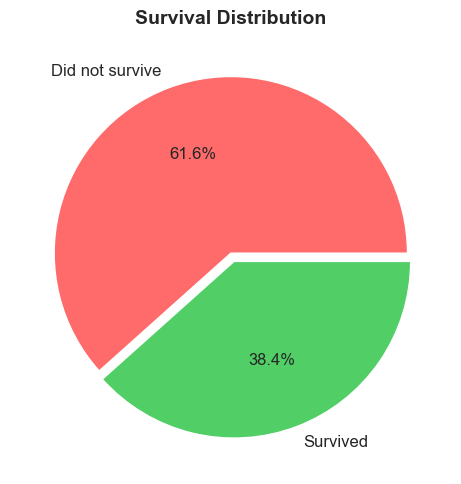

In [32]:
# Survival distribution
fig, ax = plt.subplots(figsize=(6, 5))
df["Survived"].value_counts().plot(kind="pie", autopct="%1.1f%%",
                                    colors=["#ff6b6b", "#51cf66"],
                                    labels=["Did not survive", "Survived"],
                                    explode=(0, 0.05), ax=ax)
ax.set_title("Survival Distribution", fontsize=14, fontweight="bold")
ax.set_ylabel("")
plt.tight_layout()
plt.show()

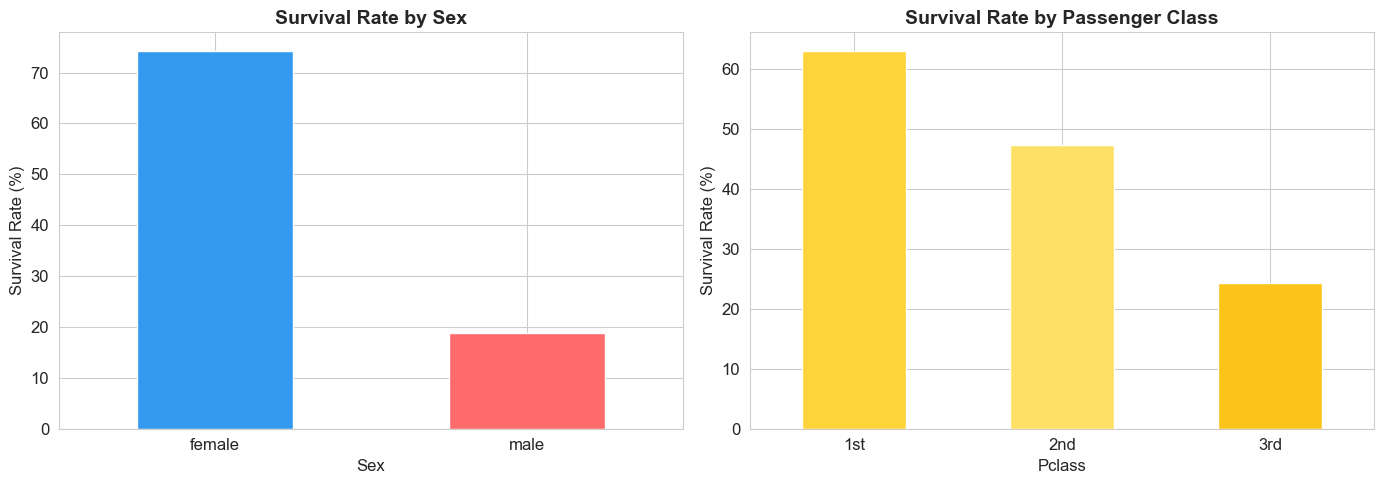

Women survival: 74.2%
Men survival: 18.9%


In [33]:
# Survival by Sex and Class
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sex_survival = df.groupby("Sex")["Survived"].mean() * 100
sex_survival.plot(kind="bar", color=["#339af0", "#ff6b6b"], ax=axes[0])
axes[0].set_title("Survival Rate by Sex", fontsize=14, fontweight="bold")
axes[0].set_ylabel("Survival Rate (%)")
axes[0].set_xticklabels(axes[0].get_xticklabels(), rotation=0)

pclass_survival = df.groupby("Pclass")["Survived"].mean() * 100
pclass_survival.plot(kind="bar", ax=axes[1], color=["#ffd43b", "#ffe066", "#fcc419"])
axes[1].set_title("Survival Rate by Passenger Class", fontsize=14, fontweight="bold")
axes[1].set_ylabel("Survival Rate (%)")
axes[1].set_xticklabels(["1st", "2nd", "3rd"], rotation=0)

plt.tight_layout()
plt.show()

print(f"Women survival: {df[df['Sex']=='female']['Survived'].mean()*100:.1f}%")
print(f"Men survival: {df[df['Sex']=='male']['Survived'].mean()*100:.1f}%")

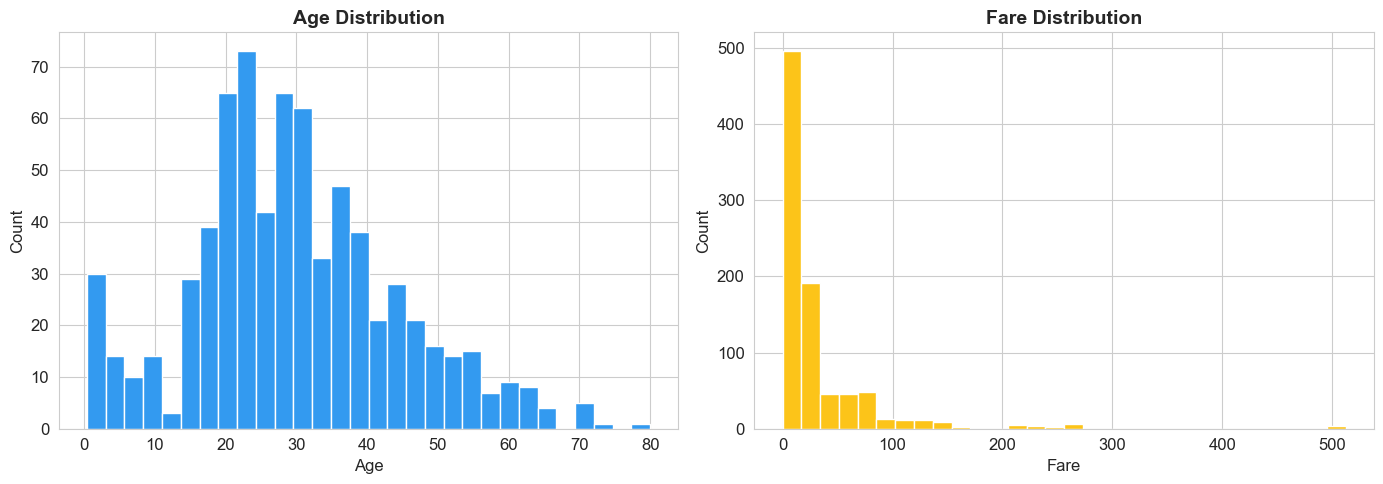

In [34]:
# Age and Fare distributions
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

df["Age"].hist(bins=30, ax=axes[0], color="#339af0", edgecolor="white")
axes[0].set_title("Age Distribution", fontsize=14, fontweight="bold")
axes[0].set_xlabel("Age")
axes[0].set_ylabel("Count")

df["Fare"].hist(bins=30, ax=axes[1], color="#fcc419", edgecolor="white")
axes[1].set_title("Fare Distribution", fontsize=14, fontweight="bold")
axes[1].set_xlabel("Fare")
axes[1].set_ylabel("Count")

plt.tight_layout()
plt.show()

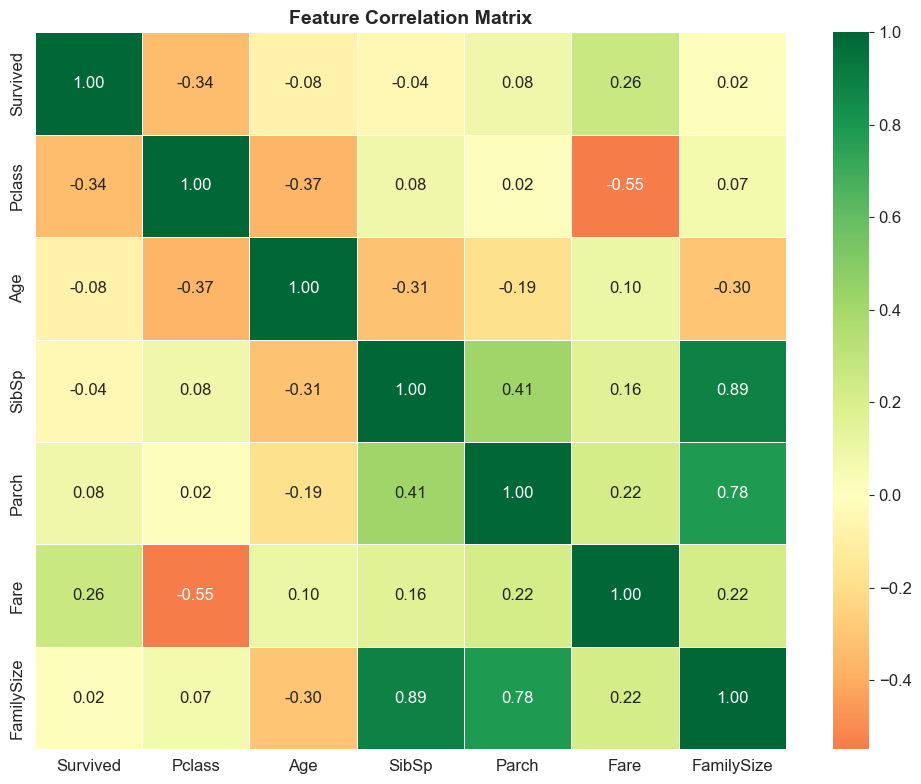


Top correlations with Survival:
Survived      1.000000
Fare          0.257307
Parch         0.081629
FamilySize    0.016639
SibSp        -0.035322
Age          -0.077221
Pclass       -0.338481
Name: Survived, dtype: float64


In [35]:
# Correlation heatmap
df["FamilySize"] = df["SibSp"] + df["Parch"] + 1
numeric_cols = ["Survived", "Pclass", "Age", "SibSp", "Parch", "Fare", "FamilySize"]
corr = df[numeric_cols].corr()

fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(corr, annot=True, cmap="RdYlGn", center=0, fmt=".2f", linewidths=0.5, ax=ax)
ax.set_title("Feature Correlation Matrix", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

print("\nTop correlations with Survival:")
print(corr["Survived"].sort_values(ascending=False))

In [36]:
# Feature engineering
df["Age"] = df["Age"].fillna(df["Age"].median())
df["Fare"] = df["Fare"].fillna(df["Fare"].median())
df["Embarked"] = df["Embarked"].fillna(df["Embarked"].mode()[0])

df["FamilySize"] = df["SibSp"] + df["Parch"] + 1
df["IsAlone"] = (df["FamilySize"] == 1).astype(int)
df["FarePerPerson"] = df["Fare"] / df["FamilySize"]
df["AgeBin"] = pd.cut(df["Age"], bins=[0, 12, 18, 35, 60, 100], labels=[0, 1, 2, 3, 4]).astype(float)

# Encode categorical variables
le_sex = LabelEncoder()
le_embarked = LabelEncoder()
df["Sex_encoded"] = le_sex.fit_transform(df["Sex"])
df["Embarked_encoded"] = le_embarked.fit_transform(df["Embarked"])

print("Feature engineering complete!")
print(f"Label mappings: Sex={dict(zip(le_sex.classes_, le_sex.transform(le_sex.classes_)))}")
print(f"Label mappings: Embarked={dict(zip(le_embarked.classes_, le_embarked.transform(le_embarked.classes_)))}")

Feature engineering complete!
Label mappings: Sex={'female': np.int64(0), 'male': np.int64(1)}
Label mappings: Embarked={'C': np.int64(0), 'Q': np.int64(1), 'S': np.int64(2)}


In [37]:
# Define features and target
features = ["Pclass", "Sex_encoded", "Age", "SibSp", "Parch", "Fare", 
            "Embarked_encoded", "FamilySize", "IsAlone", "FarePerPerson", "AgeBin"]

X = df[features]
y = df["Survived"]

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# Scale features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(f"Training set: {len(X_train)} samples")
print(f"Test set: {len(X_test)} samples")
print(f"Features: {features}")

Training set: 712 samples
Test set: 179 samples
Features: ['Pclass', 'Sex_encoded', 'Age', 'SibSp', 'Parch', 'Fare', 'Embarked_encoded', 'FamilySize', 'IsAlone', 'FarePerPerson', 'AgeBin']


In [38]:
# Load artifacts
model = joblib.load(f"{MODEL_DIR}/titanic_model.pkl")
scaler = joblib.load(f"{MODEL_DIR}/scaler.pkl")
features = joblib.load(f"{MODEL_DIR}/features.pkl")
le_sex = joblib.load(f"{MODEL_DIR}/le_sex.pkl")
le_embarked = joblib.load(f"{MODEL_DIR}/le_embarked.pkl")

print("Model artifacts loaded successfully!")

Model artifacts loaded successfully!


In [39]:
# Prediction function
def predict_survival(pclass, sex, age, sibsp, parch, fare, embarked):
    """Predict Titanic survival probability."""
    family_size = sibsp + parch + 1
    is_alone = 1 if family_size == 1 else 0
    fare_per_person = fare / family_size
    
    age_bin = 0
    if age > 12: age_bin = 1
    if age > 18: age_bin = 2
    if age > 35: age_bin = 3
    if age > 60: age_bin = 4

    sample = pd.DataFrame({
        "Pclass": [pclass], "Sex_encoded": [le_sex.transform([sex])[0]],
        "Age": [age], "SibSp": [sibsp], "Parch": [parch], "Fare": [fare],
        "Embarked_encoded": [le_embarked.transform([embarked])[0]],
        "FamilySize": [family_size], "IsAlone": [is_alone],
        "FarePerPerson": [fare_per_person], "AgeBin": [age_bin]
    })

    sample_scaled = scaler.transform(sample)
    survival = int(model.predict(sample_scaled)[0])
    probability = float(model.predict_proba(sample_scaled)[0][1])

    return {"survival": survival, "probability": probability}

In [40]:
# Example predictions
print("=" * 50)
print("EXAMPLE PREDICTIONS")
print("=" * 50)

# Example 1: 3rd class male, 25 years old
result1 = predict_survival(pclass=3, sex="male", age=25, sibsp=0, parch=0, fare=7.25, embarked="S")
print(f"\nPassenger 1 (3rd class, male, 25): {result1}")

# Example 2: 1st class female, 30 years old
result2 = predict_survival(pclass=1, sex="female", age=30, sibsp=1, parch=1, fare=100, embarked="C")
print(f"Passenger 2 (1st class, female, 30): {result2}")

# Example 3: 2nd class male, 40 years old
result3 = predict_survival(pclass=2, sex="male", age=40, sibsp=1, parch=0, fare=30, embarked="Q")
print(f"Passenger 3 (2nd class, male, 40): {result3}")

EXAMPLE PREDICTIONS

Passenger 1 (3rd class, male, 25): {'survival': 0, 'probability': 0.010583373712207892}
Passenger 2 (1st class, female, 30): {'survival': 1, 'probability': 0.998277352125732}
Passenger 3 (2nd class, male, 40): {'survival': 0, 'probability': 0.01471323239388266}


In [41]:
# Train GradientBoosting model
from sklearn.ensemble import GradientBoostingClassifier

model = GradientBoostingClassifier(n_estimators=200, max_depth=5, learning_rate=0.1, random_state=42)

# Cross-validation
cv_scores = cross_val_score(model, X_train_scaled, y_train, cv=5, scoring="accuracy")
print(f"Cross-Validation Accuracy: {cv_scores.mean():.4f} (+/- {cv_scores.std():.4f})")

# Train
model.fit(X_train_scaled, y_train)

# Test predictions
y_pred = model.predict(X_test_scaled)
y_proba = model.predict_proba(X_test_scaled)[:, 1]

# Metrics
test_acc = accuracy_score(y_test, y_pred)
test_auc = roc_auc_score(y_test, y_proba)

print(f"Test Accuracy: {test_acc:.4f}")
print(f"Test AUC-ROC: {test_auc:.4f}")

best_name = "GradientBoosting"


Cross-Validation Accuracy: 0.8021 (+/- 0.0369)
Test Accuracy: 0.8101
Test AUC-ROC: 0.8088


In [42]:
print("=" * 60)
print("LIFEBOAT MODEL SUMMARY")
print("=" * 60)
print(f"""
Model: {best_name}
Test Accuracy: {test_acc*100:.2f}%
Test AUC-ROC: {test_auc:.4f}

Key Features:
- Sex (strongest predictor)
- Passenger Class
- Fare
- Age
- Family Size

Files saved:
- models/titanic_model.pkl
- models/scaler.pkl
- models/features.pkl
- models/le_sex.pkl
- models/le_embarked.pkl
""")
print("=" * 60)

LIFEBOAT MODEL SUMMARY

Model: GradientBoosting
Test Accuracy: 81.01%
Test AUC-ROC: 0.8088

Key Features:
- Sex (strongest predictor)
- Passenger Class
- Fare
- Age
- Family Size

Files saved:
- models/titanic_model.pkl
- models/scaler.pkl
- models/features.pkl
- models/le_sex.pkl
- models/le_embarked.pkl



---*Notebook complete! Model is ready for deployment.*
